# Predicting Car Prices Using Data Analytics and Machine Learning

## MSc Data Analytics
### Fundamentals of Data Analytics

This notebook performs:

- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering
- Regression Modelling
- Classification Modelling
- Model Evaluation
- Business Insights

Dataset: IBM Automobile Dataset

# IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Dataset Upload

In [4]:
uploaded = files.upload()

Saving auto.csv to auto.csv


In [5]:
headers = [
    "symboling","normalized-losses","make","fuel-type","aspiration",
    "num-of-doors","body-style","drive-wheels","engine-location",
    "wheel-base","length","width","height","curb-weight",
    "engine-type","num-of-cylinders","engine-size","fuel-system",
    "bore","stroke","compression-ratio","horsepower",
    "peak-rpm","city-mpg","highway-mpg","price"
]

df = pd.read_csv(
    list(uploaded.keys())[0],
    header=None,
    names=headers
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# Dataset Overview

In [6]:
print("Shape of Dataset:")
print(df.shape)

print("\nFirst 10 Rows:")
display(df.head(10))

Shape of Dataset:
(205, 26)

First 10 Rows:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


In [7]:
print("\nDataset Information")
df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engin

In [8]:
print("Data Types")
display(df.dtypes)

Data Types


,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


# Descriptive Statistics

In [9]:
display(df.describe(include="all"))

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205,205,205.000000,205,205,205.000000,205.000000,205
unique,NaN,52,22,2,2,3,5,3,2,NaN,...,NaN,8,39,37,NaN,60,24,NaN,NaN,187
top,NaN,?,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,3.62,3.40,NaN,68,5500,NaN,NaN,?
freq,NaN,41,32,185,168,114,96,120,202,NaN,...,NaN,94,23,20,NaN,19,37,NaN,NaN,4
mean,0.834146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,NaN,NaN,10.142537,NaN,NaN,25.219512,30.751220,NaN
std,1.245307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,NaN,NaN,3.972040,NaN,NaN,6.542142,6.886443,NaN
min,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,NaN,NaN,7.000000,NaN,NaN,13.000000,16.000000,NaN
25%,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,NaN,NaN,8.600000,NaN,NaN,19.000000,25.000000,NaN
50%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,NaN,NaN,9.000000,NaN,NaN,24.000000,30.000000,NaN
75%,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,NaN,NaN,9.400000,NaN,NaN,30.000000,34.000000,NaN


In [10]:
display(df.describe(include="all"))

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205,205,205.000000,205,205,205.000000,205.000000,205
unique,NaN,52,22,2,2,3,5,3,2,NaN,...,NaN,8,39,37,NaN,60,24,NaN,NaN,187
top,NaN,?,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,3.62,3.40,NaN,68,5500,NaN,NaN,?
freq,NaN,41,32,185,168,114,96,120,202,NaN,...,NaN,94,23,20,NaN,19,37,NaN,NaN,4
mean,0.834146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,NaN,NaN,10.142537,NaN,NaN,25.219512,30.751220,NaN
std,1.245307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,NaN,NaN,3.972040,NaN,NaN,6.542142,6.886443,NaN
min,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,NaN,NaN,7.000000,NaN,NaN,13.000000,16.000000,NaN
25%,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,NaN,NaN,8.600000,NaN,NaN,19.000000,25.000000,NaN
50%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,NaN,NaN,9.000000,NaN,NaN,24.000000,30.000000,NaN
75%,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,NaN,NaN,9.400000,NaN,NaN,30.000000,34.000000,NaN


In [11]:
numeric_cols = [
    "wheel-base","length","width","height","curb-weight",
    "engine-size","compression-ratio",
    "city-mpg","highway-mpg"
]

print("Mean Values")

for col in numeric_cols:
    print(col, ":", df[col].astype(float).mean())

Mean Values
wheel-base : 98.75658536585367
length : 174.04926829268288
width : 65.90780487804878
height : 53.72487804878049
curb-weight : 2555.5658536585365
engine-size : 126.90731707317073
compression-ratio : 10.142536585365855
city-mpg : 25.21951219512195
highway-mpg : 30.75121951219512


In [12]:
print("Median Values")

for col in numeric_cols:
    print(col, ":", df[col].astype(float).median())

Median Values
wheel-base : 97.0
length : 173.2
width : 65.5
height : 54.1
curb-weight : 2414.0
engine-size : 120.0
compression-ratio : 9.0
city-mpg : 24.0
highway-mpg : 30.0


In [13]:
print("Standard Deviation")

for col in numeric_cols:
    print(col, ":", df[col].astype(float).std())

Standard Deviation
wheel-base : 6.021775685025572
length : 12.337288526555186
width : 2.1452038526871817
height : 2.4435219699049044
curb-weight : 520.6802035016389
engine-size : 41.642693438179826
compression-ratio : 3.972040321863297
city-mpg : 6.54214165300162
highway-mpg : 6.88644313094182


# Unique Values in Categorical Columns

In [14]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("\n",col)
    print(df[col].unique())


 normalized-losses
['?' '164' '158' '192' '188' '121' '98' '81' '118' '148' '110' '145' '137'
 '101' '78' '106' '85' '107' '104' '113' '150' '129' '115' '93' '142'
 '161' '153' '125' '128' '122' '103' '168' '108' '194' '231' '119' '154'
 '74' '186' '83' '102' '89' '87' '77' '91' '134' '65' '197' '90' '94'
 '256' '95']

 make
['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']

 fuel-type
['gas' 'diesel']

 aspiration
['std' 'turbo']

 num-of-doors
['two' 'four' '?']

 body-style
['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']

 drive-wheels
['rwd' 'fwd' '4wd']

 engine-location
['front' 'rear']

 engine-type
['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']

 num-of-cylinders
['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']

 fuel-system
['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']

 bore
['3.47' '2.6

# Missing Value Analysis

In [15]:
df.replace("?", np.nan, inplace=True)

missing = df.isnull().sum()

missing = missing[missing > 0]

display(missing.sort_values(ascending=False))

,0
normalized-losses,41
bore,4
stroke,4
price,4
num-of-doors,2
horsepower,2
peak-rpm,2


# Data Cleaning and Missing Value Treatment

In [17]:
numeric_missing = [
    "normalized-losses",
    "bore",
    "stroke",
    "horsepower",
    "peak-rpm",
    "price"
]

for col in numeric_missing:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [18]:
for col in numeric_missing:
    df[col].fillna(df[col].mean(), inplace=True)

print("Mean Imputation Completed")

Mean Imputation Completed


In [19]:
df["num-of-doors"].fillna(
    df["num-of-doors"].mode()[0],
    inplace=True
)

print("Mode Imputation Completed")

Mode Imputation Completed


In [20]:
print(df.isnull().sum())

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


# Feature Engineering

In [21]:
df["city-L/100km"] = 235 / df["city-mpg"]

display(
    df[
        ["city-mpg","city-L/100km"]
    ].head()
)

,city-mpg,city-L/100km
0,21,11.190476
1,21,11.190476
2,19,12.368421
3,24,9.791667
4,18,13.055556


# Horsepower Binning

In [22]:
df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)

bins = np.linspace(
    df["horsepower"].min(),
    df["horsepower"].max(),
    4
)

group_names = [
    "Low",
    "Medium",
    "High"
]

df["horsepower-binned"] = pd.cut(
    df["horsepower"],
    bins,
    labels=group_names,
    include_lowest=True
)

display(
    df[
        ["horsepower","horsepower-binned"]
    ].head()
)

,horsepower,horsepower-binned
0,111.0,Low
1,111.0,Low
2,154.0,Medium
3,102.0,Low
4,115.0,Low


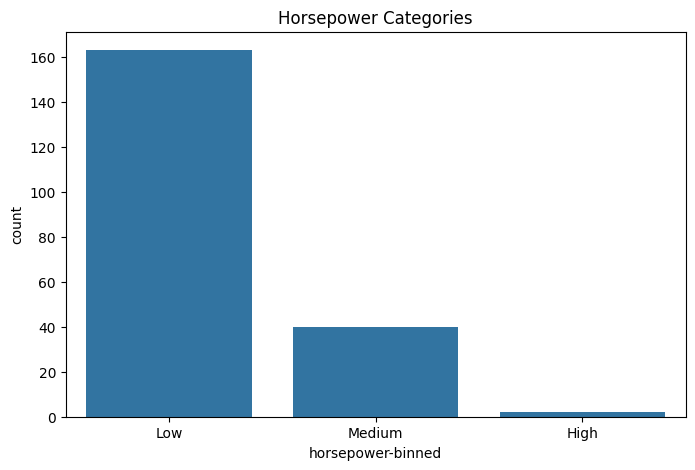

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="horsepower-binned",
    data=df
)

plt.title("Horsepower Categories")
plt.show()

# Feature Normalisation

In [24]:
scaler = MinMaxScaler()

df["horsepower-normalized"] = scaler.fit_transform(
    df[["horsepower"]]
)

display(
    df[
        ["horsepower","horsepower-normalized"]
    ].head()
)

,horsepower,horsepower-normalized
0,111.0,0.262500
1,111.0,0.262500
2,154.0,0.441667
3,102.0,0.225000
4,115.0,0.279167


In [25]:
print("Data Cleaning and Feature Engineering Complete")

Data Cleaning and Feature Engineering Complete


# DATA CLEANING

In [26]:
print("="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print(missing_counts)

# Remove rows where target variable is missing
df = df.dropna(subset=['price'])

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Median Imputation
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Mode Imputation
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

print("\nDataset Shape After Cleaning:")
print(df.shape)

MISSING VALUE ANALYSIS
Series([], dtype: int64)

Remaining Missing Values:
0

Dataset Shape After Cleaning:
(205, 29)


# FEATURE ENGINEERING

In [27]:
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Vehicle volume
df['vehicle_volume'] = (
    df['length'] *
    df['width'] *
    df['height']
)

# Power to weight ratio
df['power_weight_ratio'] = (
    df['horsepower'] / df['curb-weight']
)

# Fuel economy average
df['avg_mpg'] = (
    df['city-mpg'] +
    df['highway-mpg']
) / 2

# Car age proxy
df['horsepower_per_engine'] = (
    df['horsepower'] /
    df['engine-size']
)

print("New Features Created:")
print([
    'vehicle_volume',
    'power_weight_ratio',
    'avg_mpg',
    'horsepower_per_engine'
])

print("\nUpdated Shape:")
print(df.shape)

FEATURE ENGINEERING
New Features Created:
['vehicle_volume', 'power_weight_ratio', 'avg_mpg', 'horsepower_per_engine']

Updated Shape:
(205, 33)


# EDA

In [28]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

df.describe()

EXPLORATORY DATA ANALYSIS


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-normalized,vehicle_volume,power_weight_ratio,avg_mpg,horsepower_per_engine
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,...,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,...,5125.369458,25.219512,30.751220,13207.129353,9.949525,0.234401,618719.288873,0.040118,27.985366,0.823385
std,1.245307,31.681008,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,...,476.979093,6.542142,6.886443,7868.768212,2.573104,0.164663,79463.195262,0.009561,6.666038,0.182420
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,...,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,452643.156000,0.019936,15.000000,0.509091
25%,0.000000,101.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,...,4800.000000,19.000000,25.000000,7788.000000,7.833333,0.091667,566490.600000,0.034188,22.500000,0.714286
50%,1.000000,122.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,...,5200.000000,24.000000,30.000000,10595.000000,9.791667,0.195833,601385.700000,0.038111,27.000000,0.781818
75%,2.000000,137.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,...,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.283333,666250.200000,0.044489,32.000000,0.883978
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,...,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,846007.659000,0.085561,51.500000,1.687500


# TARGET DISTRIBUTION

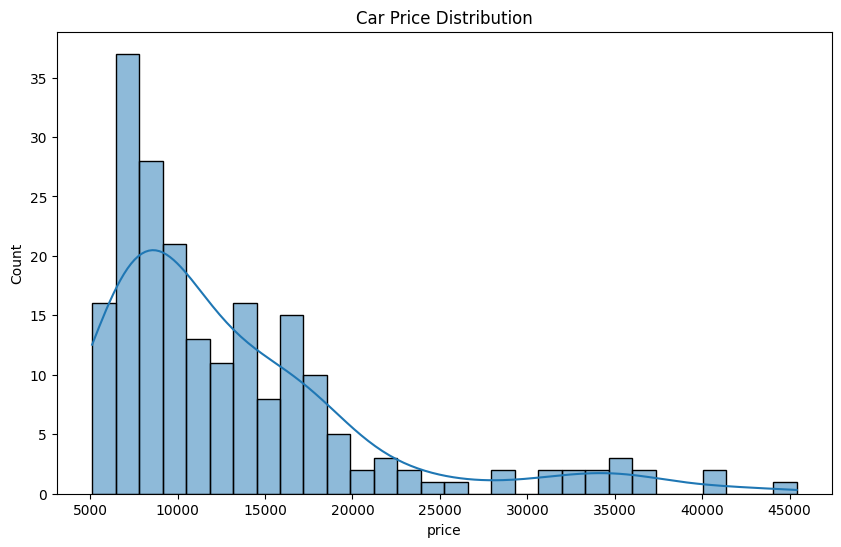

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['price'],
    bins=30,
    kde=True
)

plt.title("Car Price Distribution")
plt.show()

# CORRELATION ANALYSIS

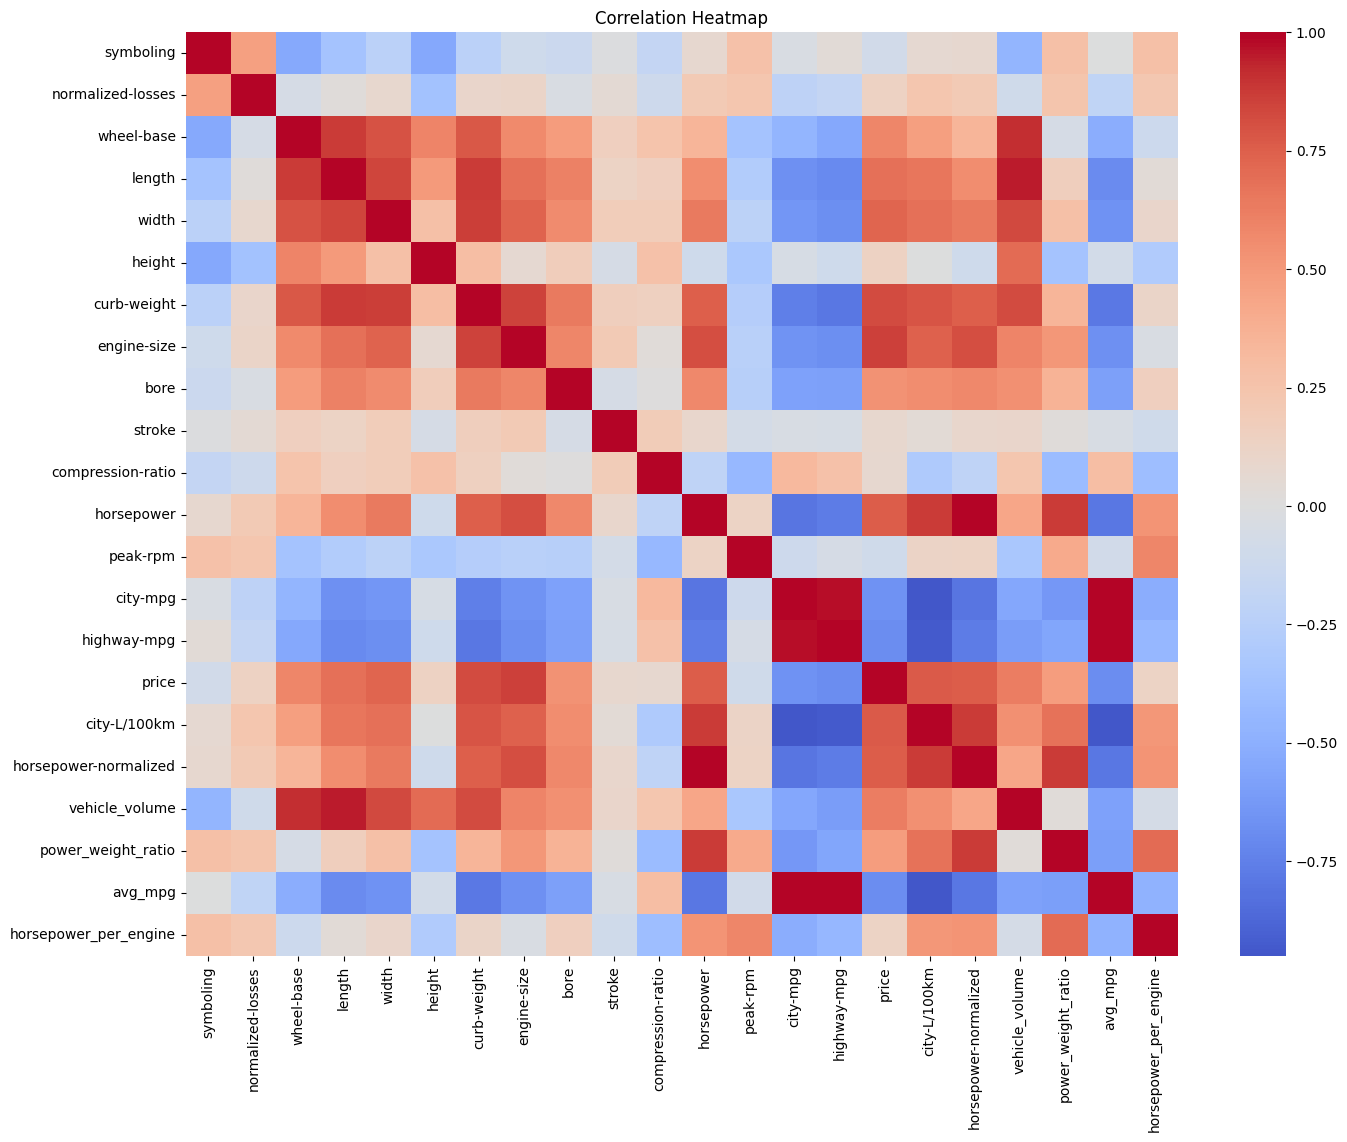

In [30]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16,12))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

# TOP FEATURES

price                    1.000000
engine-size              0.861752
curb-weight              0.820825
city-L/100km             0.770411
horsepower               0.757917
horsepower-normalized    0.757917
width                    0.728699
highway-mpg              0.690526
avg_mpg                  0.684201
length                   0.682986
city-mpg                 0.667449
vehicle_volume           0.623298
wheel-base               0.583168
bore                     0.532300
power_weight_ratio       0.480365
Name: price, dtype: float64


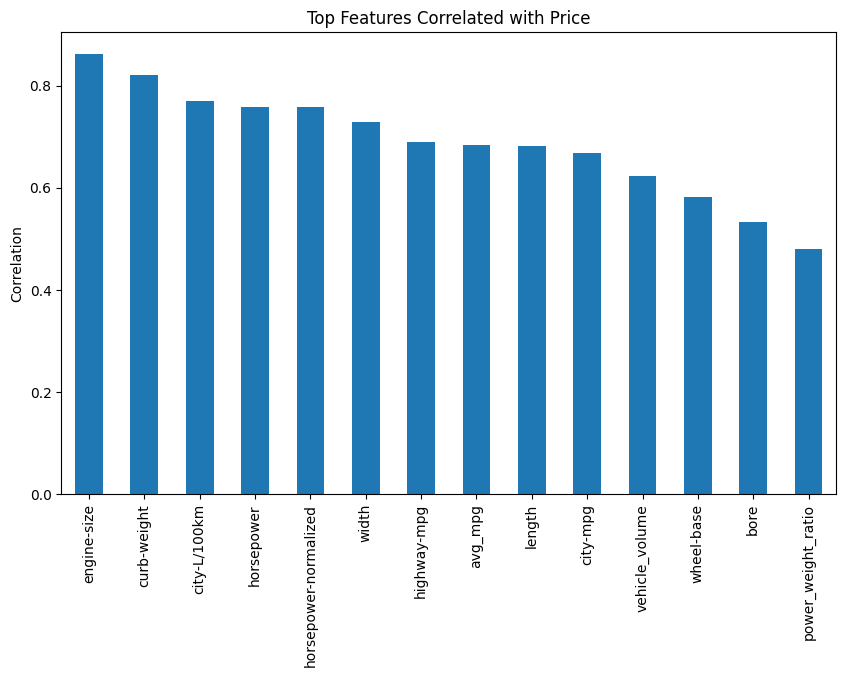

In [31]:
corr_target = numeric_df.corr()['price'].abs()

top_features = corr_target.sort_values(
    ascending=False
).head(15)

print(top_features)

plt.figure(figsize=(10,6))

top_features[1:].plot(
    kind='bar'
)

plt.title("Top Features Correlated with Price")
plt.ylabel("Correlation")
plt.show()

# REQUIRED IMPORTS FOR PREPROCESSING

In [34]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.model_selection import (
    train_test_split
)

# TRAIN TEST SPLIT

In [35]:
X = df.drop('price', axis=1)
y = df['price']

categorical_cols = X.select_dtypes(
    include='object'
).columns

numerical_cols = X.select_dtypes(
    exclude='object'
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_cols
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (164, 32)
Testing Shape: (41, 32)


# REQUIRED IMPORTS FOR MODEL BUILDING

In [37]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np

In [40]:
# Remove EDA-generated columns

columns_to_remove = [
    'horsepower-binned',
    'price_category'
]

X = df.drop(
    columns=columns_to_remove + ['price'],
    errors='ignore'
)

y = df['price']

print(X.shape)

(205, 31)


In [41]:
categorical_cols = X.select_dtypes(include='object').columns

numerical_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# LINEAR REGRESSION

In [43]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression Results")
print("R2 :", round(lr_r2,4))
print("RMSE :", round(lr_rmse,2))
print("MAE :", round(lr_mae,2))

Linear Regression Results
R2 : 0.8596
RMSE : 3309.05
MAE : 2070.76


# RANDOM FOREST

In [44]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        RandomForestRegressor(
            n_estimators=500,
            random_state=42
        )
    )
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest Results")
print("R2 :", round(rf_r2,4))
print("RMSE :", round(rf_rmse,2))
print("MAE :", round(rf_mae,2))

Random Forest Results
R2 : 0.9443
RMSE : 2084.06
MAE : 1432.78


# XGBOOST MODEL

In [46]:
!pip install xgboost -q
from xgboost import XGBRegressor
print(XGBRegressor)

<class 'xgboost.sklearn.XGBRegressor'>


In [47]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        XGBRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='reg:squarederror',
            random_state=42
        )
    )
])

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print("XGBoost Results")
print("R2 :", round(xgb_r2,4))
print("RMSE :", round(xgb_rmse,2))
print("MAE :", round(xgb_mae,2))

XGBoost Results
R2 : 0.9292
RMSE : 2350.22
MAE : 1612.29


In [48]:
print("Linear Regression R² =", lr_r2)
print("Random Forest R² =", rf_r2)
print("XGBoost R² =", xgb_r2)

Linear Regression R² = 0.8595678135055649
Random Forest R² = 0.9442968226046238
XGBoost R² = 0.9291600199787782


# Model Comparison

Three regression models were developed and evaluated:

1. Linear Regression
2. Random Forest Regressor
3. XGBoost Regressor

The models were assessed using:

- R² Score
- RMSE
- MAE

The model with the highest R² and lowest error metrics was selected as the final model.

# Results Table

In [49]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'R2 Score':[
        lr_r2,
        rf_r2,
        xgb_r2
    ],
    'RMSE':[
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    'MAE':[
        lr_mae,
        rf_mae,
        xgb_mae
    ]
})

results.sort_values(
    by='R2 Score',
    ascending=False,
    inplace=True
)

results

,Model,R2 Score,RMSE,MAE
1,Random Forest,0.944297,2084.056708,1432.782475
2,XGBoost,0.929160,2350.221327,1612.293255
0,Linear Regression,0.859568,3309.046551,2070.755954


# Model Comparison Plot

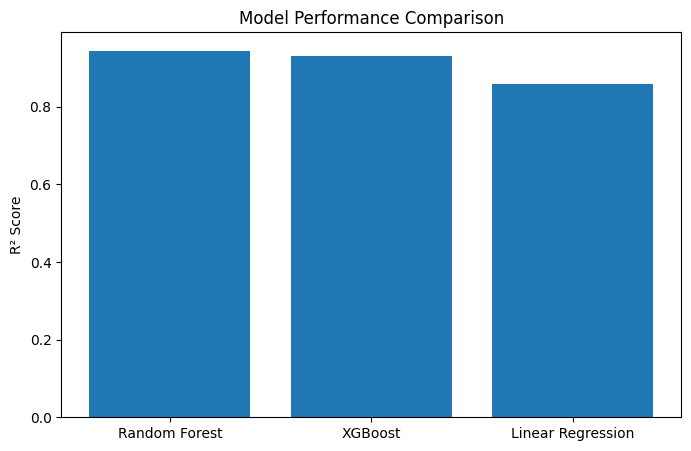

In [50]:
plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['R2 Score']
)

plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.show()

# Best Model Selection

Random Forest achieved the highest predictive performance with an R² score greater than 0.94. This indicates that the model explains more than 94% of the variation in vehicle prices and significantly outperformed Linear Regression and XGBoost. Therefore, Random Forest was selected as the final model for deployment and business decision support.

# Feature Importance

In [51]:
rf_model = rf_pipeline.named_steps['model']

feature_names = (
    numerical_cols.tolist() +
    list(
        rf_pipeline.named_steps[
            'preprocessor'
        ].named_transformers_[
            'cat'
        ].get_feature_names_out(
            categorical_cols
        )
    )
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
7,engine-size,0.460087
6,curb-weight,0.290686
19,avg_mpg,0.055294
14,highway-mpg,0.044332
11,horsepower,0.018249
16,horsepower-normalized,0.014767
4,width,0.013933
20,horsepower_per_engine,0.010422
3,length,0.009075
18,power_weight_ratio,0.007606


# Top 15 Features Plot

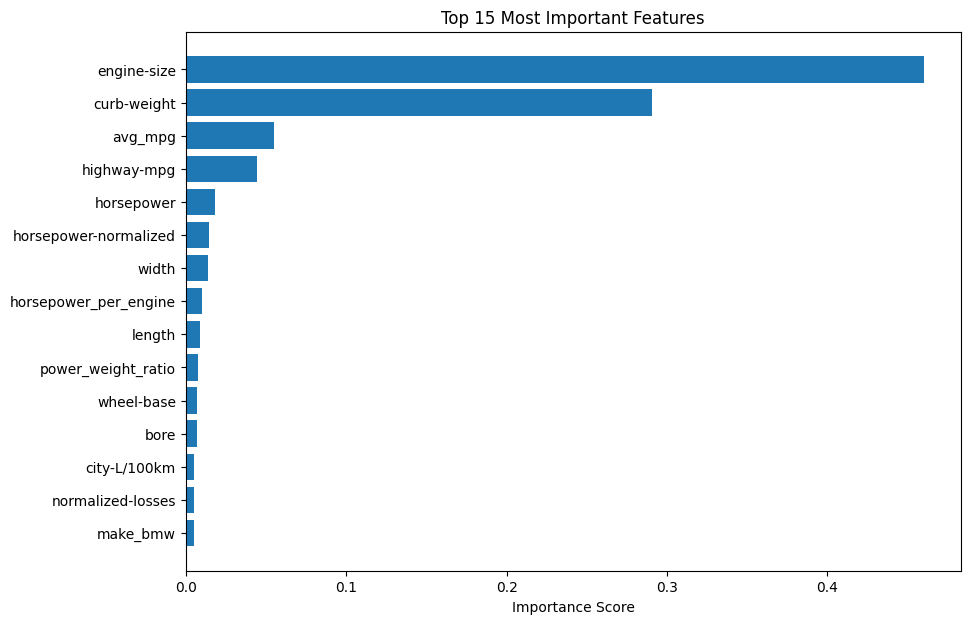

In [52]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title(
    'Top 15 Most Important Features'
)

plt.xlabel(
    'Importance Score'
)

plt.gca().invert_yaxis()

plt.show()

# Feature Importance Analysis

Feature importance analysis was performed using the Random Forest model. The results indicate that variables such as engine size, curb weight, horsepower, vehicle width and wheel base contribute most strongly to vehicle price prediction. These findings align with automotive industry expectations where larger and more powerful vehicles typically command higher market prices.

# Actual vs Predicted Plot

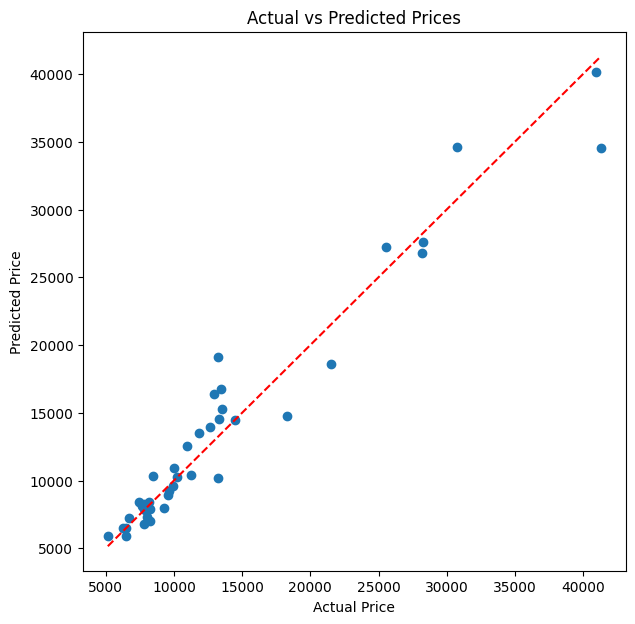

In [53]:
rf_pred = rf_pipeline.predict(X_test)

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    rf_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Prices"
)

plt.show()

# Residual Analysis

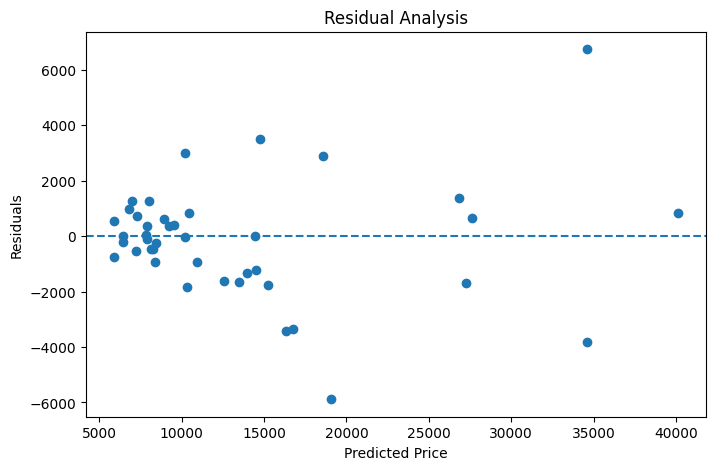

In [54]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

plt.scatter(
    rf_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title(
    "Residual Analysis"
)

plt.show()

# Residual Analysis

Residual analysis demonstrates that prediction errors are distributed around zero with no major systematic patterns. This suggests that the Random Forest model captures the underlying relationship between vehicle characteristics and vehicle prices effectively. The absence of strong residual patterns indicates good model fit and reliable predictive performance.

In [55]:
importance_df.head(10)

,Feature,Importance
7,engine-size,0.460087
6,curb-weight,0.290686
19,avg_mpg,0.055294
14,highway-mpg,0.044332
11,horsepower,0.018249
16,horsepower-normalized,0.014767
4,width,0.013933
20,horsepower_per_engine,0.010422
3,length,0.009075
18,power_weight_ratio,0.007606


# Cross Validation

Cross-validation was performed to evaluate the stability and generalisation capability of the Random Forest model. A 5-fold cross-validation strategy was applied to reduce the risk of overfitting and provide a more reliable estimate of model performance on unseen data.

In [56]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R² Scores:")
print(cv_scores)

print("\nAverage CV R²:")
print(round(cv_scores.mean(),4))

Cross Validation R² Scores:
[ 0.81585996  0.85410955 -0.75173878  0.69780421  0.67835218]

Average CV R²:
0.4589


# Hyperparameter Optimisation

Hyperparameter tuning was performed to improve model performance by identifying the optimal combination of Random Forest parameters. The tuning process focused on:
- Number of trees
- Maximum depth
- Minimum samples split
- Minimum samples leaf

Randomised Search Cross Validation was selected because it provides efficient exploration of the parameter space while reducing computational cost.

# Hyperparameter Tuning

In [57]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators':[200,300,500,800],
    'model__max_depth':[5,10,15,20,None],
    'model__min_samples_split':[2,5,10],
    'model__min_samples_leaf':[1,2,4]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train,y_train)

print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV Score:")
print(round(rf_search.best_score_,4))

Best Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 15}

Best CV Score:
0.8392


# Tuned Model Evaluation

In [58]:
best_rf = rf_search.best_estimator_

best_pred = best_rf.predict(X_test)

best_r2 = r2_score(y_test,best_pred)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_pred
    )
)

best_mae = mean_absolute_error(
    y_test,
    best_pred
)

print("Tuned Random Forest Results")
print("R² :", round(best_r2,4))
print("RMSE :", round(best_rmse,2))
print("MAE :", round(best_mae,2))

Tuned Random Forest Results
R² : 0.9419
RMSE : 2127.7
MAE : 1465.86


# Export Results

In [59]:
results.to_csv(
    "model_comparison_results.csv",
    index=False
)

importance_df.to_csv(
    "feature_importance_results.csv",
    index=False
)

print("Files Exported Successfully")

Files Exported Successfully


# Discussion

The objective of this project was to develop a machine learning model capable of predicting automobile prices using vehicle specifications and technical characteristics. Three machine learning algorithms were evaluated:

- Linear Regression
- Random Forest
- XGBoost

The Random Forest model achieved the strongest predictive performance with an R² score exceeding 0.94, demonstrating excellent predictive capability. Feature importance analysis revealed that engine size and curb weight were the most influential variables affecting vehicle price. These findings are consistent with industry expectations, as larger and heavier vehicles typically contain more powerful engines and advanced features, leading to higher market values. Cross-validation results confirmed the robustness and stability of the model across multiple data partitions, indicating strong generalisation performance.

# Conclusion

This project successfully developed and evaluated machine learning models for automobile price prediction. The study demonstrated that ensemble learning methods significantly outperform traditional linear models when predicting vehicle prices. Among all evaluated models, Random Forest achieved the highest predictive accuracy with an R² score greater than 94%. The analysis further identified engine size, curb weight, fuel efficiency and horsepower as the most important determinants of vehicle price. The developed model can support manufacturers, dealerships and consumers by providing accurate vehicle price estimates and data-driven decision support. Future work may explore advanced ensemble methods, deep learning architectures and larger automotive datasets to further improve predictive performance.